In [1]:
import geopandas as gpd
from shapely.geometry import Point, LineString, MultiLineString
import pandas as pd
from sklearn.cluster import DBSCAN
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
end_locations_to_directions_df = pd.DataFrame([
    ["E","WB"],
    ["W","EB"],
    ["N","SB"],
    ["S","NB"]
], columns=("end_location","direction"))
end_locations_to_directions_df

,end_location,direction
0,E,WB
1,W,EB
2,N,SB
3,S,NB


In [3]:
segments_filename = "E:\GitHub\WF-TDM-v9x\Scenarios\.vizTool\geo-data\segments_v901_TransitCorridors_with_New.geojson"

# Load the segments feature layer
segments_gdf = gpd.read_file(segments_filename)

# project to local crs for calcs
segments_gdf = segments_gdf.to_crs(epsg=26912)

segments_gdf

,SEGID,CITY_UGRC,CO_FIPS,DISTLRG,DISTMED,DISTSML,DISTSUPER,EFA,PLANAREA,TAZID,DISTANCE,geometry
0,NEW_0001,SWE,11,8,19,28,5,,WFRC,635,0.975491,"LINESTRING (416199.936 4556660.079, 417487.000..."
1,NEW_0002,UIN,57,5,13,24,4,,WFRC,575,0.749437,"LINESTRING (420529.000 4555259.000, 421446.961..."
2,NEW_0003,SUN,11,8,18,26,5,,WFRC,624,0.046454,"LINESTRING (413777.003 4551567.919, 413851.573..."
3,NEW_0004,CLR,11,8,18,30,5,EFA,WFRC,660,0.990516,"MULTILINESTRING ((416240.681 4549135.023, 4162..."
4,NEW_0005,LAY,11,8,20,32,5,EFA,WFRC,702,0.165947,"LINESTRING (417006.000 4547010.000, 417014.742..."
...,...,...,...,...,...,...,...,...,...,...,...,...
5514,UTA_A6,na,57,4,11,15,4,,WFRC,184,0.909265,"LINESTRING (410003.129 4566378.418, 408539.991..."
5515,UTA_A7,na,57,4,11,15,4,,WFRC,181,1.007502,"LINESTRING (408539.991 4566401.551, 406918.653..."
5516,UTA_A8,na,57,4,8,15,4,,WFRC,179,1.308368,"LINESTRING (406918.653 4566385.450, 404814.183..."
5517,UTA_A9,na,57,4,8,15,4,,WFRC,178,1.810206,"LINESTRING (404818.068 4566454.891, 401904.890..."


In [4]:
from shapely.geometry import LineString, MultiLineString, Point
import pandas as pd
import geopandas as gpd

# Function to determine direction endpoints for a LineString or MultiLineString
def get_endpoints_with_end_point_location(row):
    def extract_endpoints(geometry, seg_id):
        endpoints = []
        start_coords = geometry.coords[0]
        end_coords = geometry.coords[-1]
        start = Point(start_coords)
        end = Point(end_coords)
        
        # East-West direction
        if start_coords[0] < end_coords[0]:
            endpoints.append((start, f"{seg_id}__W"))
            endpoints.append((end, f"{seg_id}__E"))
        else:
            endpoints.append((end, f"{seg_id}__W"))
            endpoints.append((start, f"{seg_id}__E"))
        
        # North-South direction
        if start_coords[1] < end_coords[1]:
            endpoints.append((start, f"{seg_id}__S"))
            endpoints.append((end, f"{seg_id}__N"))
        else:
            endpoints.append((end, f"{seg_id}__S"))
            endpoints.append((start, f"{seg_id}__N"))
        
        return endpoints

    seg_id = row['SEGID']
    geometry = row.geometry
    endpoints = []

    if isinstance(geometry, LineString):
        endpoints = extract_endpoints(geometry, seg_id)
    elif isinstance(geometry, MultiLineString):
        for line in geometry.geoms:
            endpoints.extend(extract_endpoints(line, seg_id))

    return endpoints

# Extract endpoints from each geometry with end location information
endpoints = []
for idx, row in segments_gdf.iterrows():
    endpoints.extend(get_endpoints_with_end_point_location(row))

# Create a DataFrame for endpoints
endpoints_df = pd.DataFrame(endpoints, columns=['geometry', 'seg_end'])
endpoints_gdf = gpd.GeoDataFrame(endpoints_df, geometry='geometry', crs=segments_gdf.crs)

In [5]:
def round_to_nearest_20_meters(x, y):
    rounded_x = round(x / 20) * 20
    rounded_y = round(y / 20) * 20
    return rounded_x, rounded_y

# Apply the rounding function to each geometry
endpoints_gdf['geometry'] = endpoints_gdf['geometry'].apply(
    lambda point: Point(round_to_nearest_20_meters(point.x, point.y))
)

# Apply the rounding function and create the 'x_y' ID
endpoints_gdf['stop_id'] = endpoints_gdf['geometry'].apply(
    lambda geom: (int(geom.x), int(geom.y))
)
endpoints_gdf['stop_id'] = endpoints_gdf['stop_id'].apply(
    lambda coords: f"{coords[0]}_{coords[1]}"
)

endpoints_df = endpoints_gdf[['stop_id','seg_end']]

,stop_id,seg_end
0,416200_4556660,NEW_0001__W
1,417480_4557560,NEW_0001__E
2,416200_4556660,NEW_0001__S
3,417480_4557560,NEW_0001__N
4,420520_4555260,NEW_0002__W
...,...,...
22195,401900_4566480,UTA_A9__N
22196,400640_4567160,UTA_AA__W
22197,401900_4566480,UTA_AA__E
22198,401900_4566480,UTA_AA__S


<AxesSubplot:>

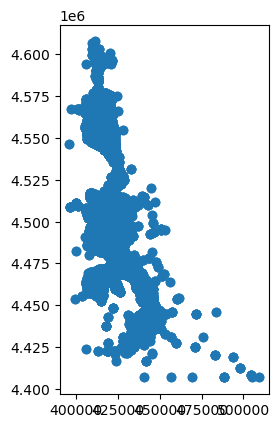

In [6]:
display(endpoints_df)
endpoints_gdf.plot()

,geometry,stop_id
0,POINT (416200.000 4556660.000),416200_4556660
1,POINT (417480.000 4557560.000),417480_4557560
2,POINT (420520.000 4555260.000),420520_4555260
3,POINT (421440.000 4556040.000),421440_4556040
4,POINT (413780.000 4551560.000),413780_4551560
...,...,...
3592,POINT (408540.000 4566400.000),408540_4566400
3593,POINT (406920.000 4566380.000),406920_4566380
3594,POINT (404820.000 4566460.000),404820_4566460
3595,POINT (401900.000 4566480.000),401900_4566480


<AxesSubplot:>

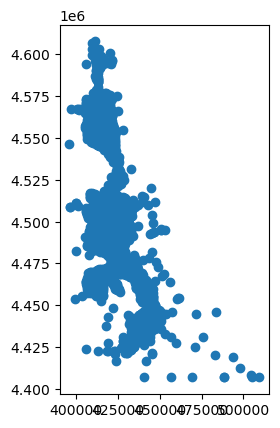

In [7]:
# Create stops_gdf by dropping duplicates based on 'stop_id'
stops_gdf = endpoints_gdf.drop(columns=(['seg_end'])).drop_duplicates(subset=['stop_id']).reset_index(drop=True)
display(stops_gdf)
stops_gdf.plot()

In [8]:
stops_gdf.to_file("_check/stops.geojson", format="GeoJSON")

In [9]:
endpoints_df[['seg_id','end_location']] = endpoints_df['seg_end'].str.rsplit('__',expand=True)
endpoints_df

,stop_id,seg_end,seg_id,end_location
0,416200_4556660,NEW_0001__W,NEW_0001,W
1,417480_4557560,NEW_0001__E,NEW_0001,E
2,416200_4556660,NEW_0001__S,NEW_0001,S
3,417480_4557560,NEW_0001__N,NEW_0001,N
4,420520_4555260,NEW_0002__W,NEW_0002,W
...,...,...,...,...
22195,401900_4566480,UTA_A9__N,UTA_A9,N
22196,400640_4567160,UTA_AA__W,UTA_AA,W
22197,401900_4566480,UTA_AA__E,UTA_AA,E
22198,401900_4566480,UTA_AA__S,UTA_AA,S


In [10]:
endpoints_df_with_direction = pd.merge(endpoints_df.drop(columns=['seg_end']), end_locations_to_directions_df, on="end_location").drop(columns=["end_location"])

# Save the DataFrame to a CSV file
endpoints_df_with_direction.to_csv("_check/stops_key.csv", index=False)

# Display the DataFrame
endpoints_df_with_direction

,stop_id,seg_id,direction
0,416200_4556660,NEW_0001,EB
1,420520_4555260,NEW_0002,EB
2,413780_4551560,NEW_0003,EB
3,416240_4550020,NEW_0004,EB
4,416240_4550720,NEW_0004,EB
...,...,...,...
22195,408540_4566400,UTA_A6,SB
22196,408540_4566400,UTA_A7,SB
22197,404820_4566460,UTA_A8,SB
22198,401900_4566480,UTA_A9,SB
